# Reparameterized Variational Inference

## Real-World Scenario: Inferring mRNA Kinetic Parameters from RNA-seq Counts

**From PML-2 Chapter 10.2**

In whole-cell modeling, every gene has two kinetic parameters that govern its mRNA pool:
- $k_{\text{syn}}$ — transcription rate (mRNAs produced per unit time)
- $k_{\text{deg}}$ — degradation rate (fraction of pool degraded per unit time)

At steady state, the mean mRNA copy number is the ratio $\lambda = k_{\text{syn}} / k_{\text{deg}}$.

RNA-seq gives us **noisy count observations** of that steady-state pool, modeled as Poisson. The catch: the data only constrains the **ratio**, not the individual rates. That makes the joint posterior $p(\log k_{\text{syn}}, \log k_{\text{deg}} \mid \text{data})$ highly correlated along the diagonal — a classic banana-shape that exposes the weakness of mean-field variational inference.

We use this as a testbed to compare three Gaussian variational families described in Section 10.2.1:

1. **Diagonal covariance** (mean field) — Section 10.2.1.1
2. **Full covariance** via Cholesky — Section 10.2.1.2
3. **Low-rank + diagonal** (factor) covariance — Section 10.2.1.3

All three are trained via the **reparameterization trick**: gradients flow through stochastic samples by writing $z = g(\boldsymbol{\phi}, \boldsymbol{\epsilon})$ with $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, Poisson

torch.manual_seed(0)
np.random.seed(0)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

## Key Formulas from PML-2 Chapter 10.2

### The ELBO (Eq. 10.9 / 10.11)
$$\mathcal{L}_{\text{ELBO}}(\boldsymbol{\psi}) \;=\; \mathbb{E}_{q_{\boldsymbol{\psi}}(\mathbf{z})}\!\left[\log p(\mathbf{x}, \mathbf{z}) - \log q_{\boldsymbol{\psi}}(\mathbf{z})\right] \;\le\; \log p(\mathbf{x})$$

Maximizing the ELBO is equivalent to minimizing $D_{\mathrm{KL}}\!\left(q_{\boldsymbol{\psi}}(\mathbf{z}) \,\|\, p(\mathbf{z}\mid\mathbf{x})\right)$. The book writes ELBO as the Polish-L glyph Ł — we use $\mathcal{L}_{\text{ELBO}}$ here so the math renders in standard LaTeX.

### Reparameterization (Eq. 10.36 / 10.40)
Rewrite $\mathbf{z} \sim q_{\boldsymbol{\psi}}(\mathbf{z})$ as $\mathbf{z} = g(\boldsymbol{\psi}, \boldsymbol{\epsilon})$ with $\boldsymbol{\epsilon} \sim p(\boldsymbol{\epsilon})$ free of $\boldsymbol{\psi}$:
$$\nabla_{\boldsymbol{\psi}}\,\mathbb{E}_{q_{\boldsymbol{\psi}}(\mathbf{z})}[f(\mathbf{z})] \;=\; \mathbb{E}_{p(\boldsymbol{\epsilon})}\!\left[\nabla_{\boldsymbol{\psi}}\, f\!\left(g(\boldsymbol{\psi}, \boldsymbol{\epsilon})\right)\right]$$

### Three Gaussian families
| Family | Reparameterization | Parameters |
|---|---|---|
| Diagonal (Eq. 10.44) | $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$ | $2d$ |
| Full (Eq. 10.52) | $\mathbf{z} = \boldsymbol{\mu} + \mathbf{L}\boldsymbol{\epsilon}$, $\boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top$ | $d + d(d{+}1)/2$ |
| Low-rank + diag (Eq. 10.57) | $\boldsymbol{\Sigma} = \mathbf{b}\mathbf{b}^\top + \mathrm{diag}(\mathbf{c}^2)$ | $3d$ |

## Step 1: The Generative Model

We parameterize on the log-scale so the rates stay positive:
- $\theta_1 = \log k_{\text{syn}}$, $\theta_2 = \log k_{\text{deg}}$
- Prior: $\theta_1, \theta_2 \sim \mathcal{N}(0, 1)$ (weakly informative)
- Likelihood (RNA-seq replicates): $y_n \sim \mathrm{Poisson}\!\left(\exp(\theta_1 - \theta_2)\right)$, for $n = 1, \dots, N$

The joint log-density is
$$\log p(\boldsymbol{\theta}, \mathbf{y}) = \log p(\boldsymbol{\theta}) + \sum_n y_n (\theta_1 - \theta_2) - N\,e^{\theta_1 - \theta_2} + \text{const}.$$

Because the likelihood depends only on $\theta_1 - \theta_2$, the data leaves the **sum** unconstrained — the posterior is a narrow diagonal band shrunk toward the origin by the prior.

In [2]:
# --- Ground-truth kinetic parameters for one gene ---
k_syn_true = 8.0    # mRNAs per unit time
k_deg_true = 2.0    # fraction per unit time -> steady-state lambda = 4 copies
lambda_true = k_syn_true / k_deg_true

theta_true = np.array([np.log(k_syn_true), np.log(k_deg_true)])
print(f"True (log k_syn, log k_deg) = ({theta_true[0]:.3f}, {theta_true[1]:.3f})")
print(f"Steady-state lambda = {lambda_true:.2f} mRNA copies")

# --- Simulate RNA-seq replicate counts ---
N = 30  # number of replicate count measurements
y_obs = np.random.poisson(lam=lambda_true, size=N)
print(f"\nObserved counts (first 10 of {N}): {y_obs[:10]}")
print(f"Sample mean: {y_obs.mean():.2f} (true lambda = {lambda_true:.2f})")

# Move to torch tensors
y_t = torch.tensor(y_obs, dtype=torch.float32)
y_sum = y_t.sum()
N_t = torch.tensor(float(N))

True (log k_syn, log k_deg) = (2.079, 0.693)
Steady-state lambda = 4.00 mRNA copies

Observed counts (first 10 of 30): [6 7 1 8 4 3 7 3 2 4]
Sample mean: 4.03 (true lambda = 4.00)


## Step 2: The Exact Posterior (via Grid Evaluation)

The posterior is 2D and unimodal, so we can compute it on a fine grid as ground truth. This is what each variational approximation should ideally match.

In [3]:
def log_joint(theta1, theta2, y_sum_val, N_val):
    """Unnormalized log p(theta, y) up to a constant in y."""
    log_prior = -0.5 * (theta1**2 + theta2**2)        # N(0,1) priors, dropped constants
    log_lik = y_sum_val * (theta1 - theta2) - N_val * np.exp(theta1 - theta2)
    return log_prior + log_lik

# Fine grid for visualization
t1_grid = np.linspace(-2.5, 4.0, 250)
t2_grid = np.linspace(-3.5, 3.0, 250)
T1, T2 = np.meshgrid(t1_grid, t2_grid)

log_post = log_joint(T1, T2, y_obs.sum(), N)
log_post -= log_post.max()       # numerical stability
post = np.exp(log_post)
post /= post.sum() * (t1_grid[1] - t1_grid[0]) * (t2_grid[1] - t2_grid[0])

# Posterior moments by numerical integration
dx = (t1_grid[1] - t1_grid[0]) * (t2_grid[1] - t2_grid[0])
mu1_exact = (T1 * post).sum() * dx
mu2_exact = (T2 * post).sum() * dx
var1_exact = ((T1 - mu1_exact)**2 * post).sum() * dx
var2_exact = ((T2 - mu2_exact)**2 * post).sum() * dx
cov_exact = ((T1 - mu1_exact) * (T2 - mu2_exact) * post).sum() * dx
corr_exact = cov_exact / np.sqrt(var1_exact * var2_exact)

print(f"Exact posterior moments:")
print(f"  E[theta1] = {mu1_exact:.3f}, sd = {np.sqrt(var1_exact):.3f}")
print(f"  E[theta2] = {mu2_exact:.3f}, sd = {np.sqrt(var2_exact):.3f}")
print(f"  corr(theta1, theta2) = {corr_exact:.3f}")
print(f"  E[theta1 - theta2] = {mu1_exact - mu2_exact:.3f} (true log lambda = {np.log(lambda_true):.3f})")

Exact posterior moments:
  E[theta1] = 0.692, sd = 0.708
  E[theta2] = -0.692, sd = 0.708
  corr(theta1, theta2) = 0.992
  E[theta1 - theta2] = 1.385 (true log lambda = 1.386)


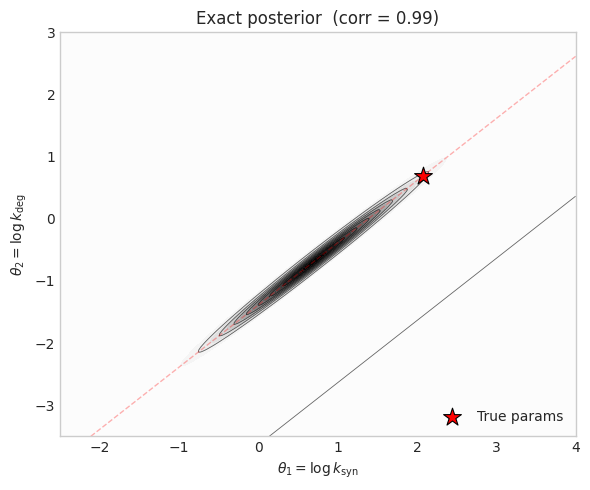

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(T1, T2, post, levels=20, cmap='Greys')
ax.contour(T1, T2, post, levels=8, colors='black', linewidths=0.6, alpha=0.6)
ax.scatter([theta_true[0]], [theta_true[1]], color='red', marker='*', s=180,
           edgecolor='black', linewidth=0.8, zorder=5, label='True params')
ax.axline((0, np.log(lambda_true) * -1 + 0), slope=1, color='red', alpha=0.3,
          linestyle='--', linewidth=1)
ax.set_xlabel(r'$\theta_1 = \log k_{\mathrm{syn}}$')
ax.set_ylabel(r'$\theta_2 = \log k_{\mathrm{deg}}$')
ax.set_title(f'Exact posterior  (corr = {corr_exact:.2f})')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

The posterior is a tight diagonal ridge — knowing $\theta_1 - \theta_2$ (the log steady-state level) doesn't tell us the rates individually. A Gaussian variational family that **ignores the off-diagonal correlation** will be a poor fit; one that captures it should match the ridge closely.

## Step 3: A Generic Reparameterized VI Trainer

All three Gaussian families share the same training loop:
1. Draw $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$
2. Form $\mathbf{z} = g(\boldsymbol{\psi}, \boldsymbol{\epsilon})$
3. Evaluate $\log p(\mathbf{z}, \mathbf{y}) - \log q_{\boldsymbol{\psi}}(\mathbf{z})$
4. Take a gradient step on the **negative** ELBO

We let each subclass implement `sample(num_samples)` (returning samples and their $\log q$) — the trainer takes care of the rest.

In [5]:
def log_joint_torch(theta, y_sum, N):
    """theta: (S, 2) tensor of (theta1, theta2) samples. Returns (S,) log p(theta, y)."""
    t1, t2 = theta[..., 0], theta[..., 1]
    log_prior = -0.5 * (t1**2 + t2**2)
    log_lik = y_sum * (t1 - t2) - N * torch.exp(t1 - t2)
    return log_prior + log_lik


def train_vi(q_module, num_steps=2000, num_samples=64, lr=1e-2, log_every=200):
    """Maximize the ELBO with Adam. Returns ELBO trace."""
    opt = torch.optim.Adam(q_module.parameters(), lr=lr)
    elbo_trace = []
    for step in range(num_steps):
        opt.zero_grad()
        z, log_q = q_module.sample(num_samples)
        log_p = log_joint_torch(z, y_sum, N_t)
        elbo = (log_p - log_q).mean()
        loss = -elbo
        loss.backward()
        opt.step()
        elbo_trace.append(elbo.item())
        if (step + 1) % log_every == 0:
            print(f"  step {step+1:>4d}  ELBO = {elbo.item():.3f}")
    return elbo_trace

## Step 4: Diagonal Gaussian (Mean Field) — Eq. 10.43–10.44

$$\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}), \quad \mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$$

We store $\log\boldsymbol{\sigma}$ for unconstrained optimization. The log-density of $\mathbf{z}$ is the sum of independent Gaussians.

In [6]:
class DiagonalGaussianVI(nn.Module):
    def __init__(self, dim=2):
        super().__init__()
        self.mu = nn.Parameter(torch.zeros(dim))
        self.log_sigma = nn.Parameter(torch.zeros(dim))   # sigma = 1 at init

    def sample(self, S):
        sigma = self.log_sigma.exp()
        eps = torch.randn(S, self.mu.shape[0])
        z = self.mu + sigma * eps                          # (S, d)
        # log q(z) for independent Gaussians
        log_q = Normal(self.mu, sigma).log_prob(z).sum(-1)
        return z, log_q

    def covariance(self):
        sigma = self.log_sigma.exp()
        return torch.diag(sigma**2)

print("Training diagonal (mean-field) VI ...")
q_diag = DiagonalGaussianVI(dim=2)
trace_diag = train_vi(q_diag, num_steps=2000)

mu_diag = q_diag.mu.detach().numpy()
Sigma_diag = q_diag.covariance().detach().numpy()
print(f"\nFitted q: mu = {mu_diag},  sigma = {np.sqrt(np.diag(Sigma_diag))}")
print(f"Covariance:\n{Sigma_diag}")

Training diagonal (mean-field) VI ...
  step  200  ELBO = 34.461
  step  400  ELBO = 41.395
  step  600  ELBO = 43.068
  step  800  ELBO = 43.311
  step 1000  ELBO = 44.537
  step 1200  ELBO = 44.336
  step 1400  ELBO = 44.126
  step 1600  ELBO = 44.504
  step 1800  ELBO = 44.390
  step 2000  ELBO = 44.299

Fitted q: mu = [ 0.687237  -0.6862268],  sigma = [0.09476933 0.09425788]
Covariance:
[[0.00898123 0.        ]
 [0.         0.00888455]]


## Step 5: Full Covariance Gaussian — Eq. 10.51–10.55

We parameterize $\boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top$ with $\mathbf{L}$ lower triangular (positive diagonal), so
$$\mathbf{z} = \boldsymbol{\mu} + \mathbf{L}\boldsymbol{\epsilon}.$$

The Jacobian determinant is the product of the diagonal of $\mathbf{L}$, and we use `torch.distributions.MultivariateNormal` for the log-density.

In [7]:
class FullCovGaussianVI(nn.Module):
    def __init__(self, dim=2):
        super().__init__()
        self.dim = dim
        self.mu = nn.Parameter(torch.zeros(dim))
        # store strictly lower-triangular part + log-diagonal separately
        self.L_offdiag = nn.Parameter(torch.zeros(dim, dim))
        self.log_diag = nn.Parameter(torch.zeros(dim))

    def cholesky(self):
        mask = torch.tril(torch.ones(self.dim, self.dim), diagonal=-1)
        return mask * self.L_offdiag + torch.diag(self.log_diag.exp())

    def sample(self, S):
        L = self.cholesky()
        eps = torch.randn(S, self.dim)
        z = self.mu + eps @ L.T                            # (S, d)
        dist = torch.distributions.MultivariateNormal(self.mu, scale_tril=L)
        log_q = dist.log_prob(z)
        return z, log_q

    def covariance(self):
        L = self.cholesky()
        return L @ L.T

print("Training full-covariance VI ...")
q_full = FullCovGaussianVI(dim=2)
trace_full = train_vi(q_full, num_steps=2000)

mu_full = q_full.mu.detach().numpy()
Sigma_full = q_full.covariance().detach().numpy()
corr_full = Sigma_full[0, 1] / np.sqrt(Sigma_full[0, 0] * Sigma_full[1, 1])
print(f"\nFitted q: mu = {mu_full}")
print(f"Covariance:\n{Sigma_full}")
print(f"Implied correlation: {corr_full:.3f}  (exact: {corr_exact:.3f})")

Training full-covariance VI ...
  step  200  ELBO = 43.123
  step  400  ELBO = 45.315
  step  600  ELBO = 45.923
  step  800  ELBO = 46.208
  step 1000  ELBO = 46.275
  step 1200  ELBO = 46.262
  step 1400  ELBO = 46.321
  step 1600  ELBO = 46.346
  step 1800  ELBO = 46.340
  step 2000  ELBO = 46.344

Fitted q: mu = [ 0.6878369 -0.6886201]
Covariance:
[[0.49560258 0.49256587]
 [0.49256587 0.49802962]]
Implied correlation: 0.991  (exact: 0.992)


## Step 6: Low-Rank + Diagonal Gaussian (Factor) — Eq. 10.57

For high-dimensional latent spaces, full covariance has $O(d^2)$ parameters. A cheap middle ground is the rank-1 plus diagonal decomposition
$$\boldsymbol{\Sigma} = \mathbf{b}\mathbf{b}^\top + \mathrm{diag}(\mathbf{c}^2),$$
with only $2d$ parameters (plus $d$ for $\boldsymbol{\mu}$). For our 2D problem this is also a full-covariance family — we use it to verify it recovers the same posterior.

In [8]:
class LowRankGaussianVI(nn.Module):
    def __init__(self, dim=2, rank=1):
        super().__init__()
        self.dim, self.rank = dim, rank
        self.mu = nn.Parameter(torch.zeros(dim))
        self.b = nn.Parameter(0.1 * torch.randn(dim, rank))
        self.log_c = nn.Parameter(torch.zeros(dim))     # diag = exp(log_c)

    def sample(self, S):
        c = self.log_c.exp()
        # z = mu + b @ eps_r + c * eps_d  with eps_r, eps_d ~ N(0, I)
        eps_r = torch.randn(S, self.rank)
        eps_d = torch.randn(S, self.dim)
        z = self.mu + eps_r @ self.b.T + c * eps_d
        # log q(z) via LowRankMultivariateNormal
        dist = torch.distributions.LowRankMultivariateNormal(
            loc=self.mu, cov_factor=self.b, cov_diag=c**2
        )
        log_q = dist.log_prob(z)
        return z, log_q

    def covariance(self):
        c = self.log_c.exp()
        return self.b @ self.b.T + torch.diag(c**2)

print("Training low-rank (rank=1) + diagonal VI ...")
q_lr = LowRankGaussianVI(dim=2, rank=1)
trace_lr = train_vi(q_lr, num_steps=2000)

mu_lr = q_lr.mu.detach().numpy()
Sigma_lr = q_lr.covariance().detach().numpy()
corr_lr = Sigma_lr[0, 1] / np.sqrt(Sigma_lr[0, 0] * Sigma_lr[1, 1])
print(f"\nFitted q: mu = {mu_lr}")
print(f"Covariance:\n{Sigma_lr}")
print(f"Implied correlation: {corr_lr:.3f}  (exact: {corr_exact:.3f})")

Training low-rank (rank=1) + diagonal VI ...
  step  200  ELBO = 34.879
  step  400  ELBO = 44.339
  step  600  ELBO = 45.236
  step  800  ELBO = 45.682
  step 1000  ELBO = 45.920
  step 1200  ELBO = 46.138
  step 1400  ELBO = 46.252
  step 1600  ELBO = 46.285
  step 1800  ELBO = 46.318
  step 2000  ELBO = 46.367

Fitted q: mu = [ 0.690414   -0.69308096]
Covariance:
[[0.5050571  0.49462315]
 [0.49462315 0.49456295]]
Implied correlation: 0.990  (exact: 0.992)


## Step 7: Side-by-Side Comparison (mirrors Figure 10.2)

We overlay the three Gaussian approximations on top of the exact posterior. The mean-field axis-aligned ellipse will be **clearly over-confident** in the direction transverse to the ridge — a textbook example of why the mode-seeking KL$(q \| p)$ makes diagonal Gaussians collapse onto a single dimension of the posterior.

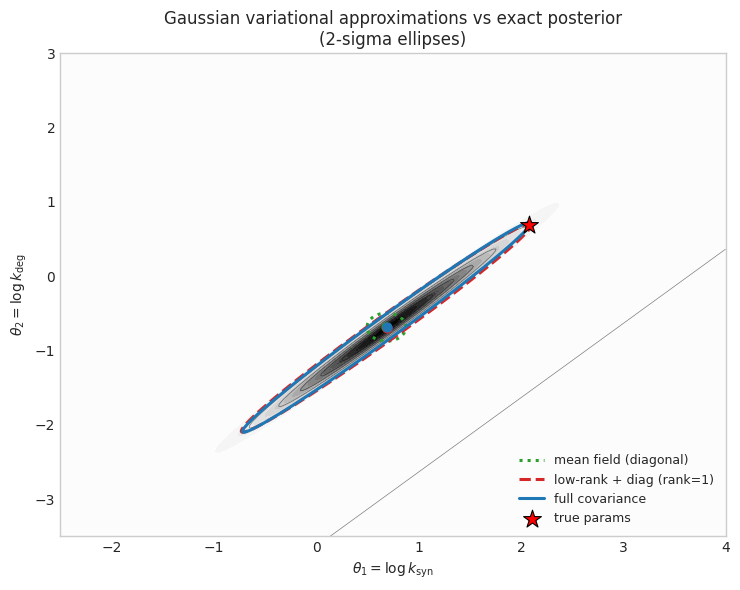

In [9]:
def gaussian_ellipse(mu, Sigma, n_std=2.0, n_pts=200):
    """Return points on the n_std-ellipse of N(mu, Sigma)."""
    L = np.linalg.cholesky(Sigma + 1e-8 * np.eye(len(mu)))
    t = np.linspace(0, 2*np.pi, n_pts)
    circle = n_std * np.vstack([np.cos(t), np.sin(t)])
    pts = mu[:, None] + L @ circle
    return pts[0], pts[1]

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.contourf(T1, T2, post, levels=20, cmap='Greys')
ax.contour(T1, T2, post, levels=6, colors='black', linewidths=0.5, alpha=0.5)

for q_mu, q_Sigma, color, style, label in [
    (mu_diag, Sigma_diag, '#2ca02c', ':',  'mean field (diagonal)'),
    (mu_lr,   Sigma_lr,   '#d62728', '--', 'low-rank + diag (rank=1)'),
    (mu_full, Sigma_full, '#1f77b4', '-',  'full covariance'),
]:
    xs, ys = gaussian_ellipse(q_mu, q_Sigma, n_std=2.0)
    ax.plot(xs, ys, color=color, linestyle=style, linewidth=2.2, label=label)
    ax.scatter([q_mu[0]], [q_mu[1]], color=color, s=40, zorder=4)

ax.scatter([theta_true[0]], [theta_true[1]], color='red', marker='*',
           s=180, edgecolor='black', linewidth=0.8, zorder=5, label='true params')
ax.set_xlabel(r'$\theta_1 = \log k_{\mathrm{syn}}$')
ax.set_ylabel(r'$\theta_2 = \log k_{\mathrm{deg}}$')
ax.set_title('Gaussian variational approximations vs exact posterior\n(2-sigma ellipses)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Step 8: Quantitative Comparison

We compare each variational family on three criteria:
1. **Mean recovery** — distance from $\mathbb{E}_q[\boldsymbol{\theta}]$ to the exact posterior mean.
2. **Correlation recovery** — does the implied correlation match the exact $\rho \approx -1$?
3. **Final ELBO** — higher is better (closer to $\log p(\mathbf{y})$).

And we report the **marginal** posterior on the well-identified direction $\theta_1 - \theta_2$, which all three methods should get right because the data strongly constrains it.

In [10]:
# Posterior variance of the well-identified contrast theta1 - theta2 under each q.
def contrast_stats(mu, Sigma):
    v = np.array([1.0, -1.0])
    return v @ mu, np.sqrt(v @ Sigma @ v)

rows = [
    ("exact",         np.array([mu1_exact, mu2_exact]),
        np.array([[var1_exact, cov_exact], [cov_exact, var2_exact]]),  None),
    ("mean field",    mu_diag, Sigma_diag, trace_diag[-50:]),
    ("low-rank+diag", mu_lr,   Sigma_lr,   trace_lr[-50:]),
    ("full cov",      mu_full, Sigma_full, trace_full[-50:]),
]

print(f"{'method':<14} | {'E[t1]':>7} {'E[t2]':>7} | {'sd(t1)':>7} {'sd(t2)':>7} | {'corr':>6} | {'E[t1-t2]':>9} {'sd(t1-t2)':>10} | {'ELBO':>8}")
print("-" * 100)
for name, mu, Sigma, trace in rows:
    c, sdc = contrast_stats(mu, Sigma)
    corr = Sigma[0, 1] / np.sqrt(Sigma[0, 0] * Sigma[1, 1])
    elbo = f"{np.mean(trace):.3f}" if trace is not None else "-"
    print(f"{name:<14} | {mu[0]:>7.3f} {mu[1]:>7.3f} | "
          f"{np.sqrt(Sigma[0,0]):>7.3f} {np.sqrt(Sigma[1,1]):>7.3f} | "
          f"{corr:>6.3f} | {c:>9.3f} {sdc:>10.4f} | {elbo:>8}")

method         |   E[t1]   E[t2] |  sd(t1)  sd(t2) |   corr |  E[t1-t2]  sd(t1-t2) |     ELBO
----------------------------------------------------------------------------------------------------
exact          |   0.692  -0.692 |   0.708   0.708 |  0.992 |     1.385     0.0912 |        -
mean field     |   0.687  -0.686 |   0.095   0.094 |  0.000 |     1.373     0.1337 |   44.305
low-rank+diag  |   0.690  -0.693 |   0.711   0.703 |  0.990 |     1.383     0.1019 |   46.334
full cov       |   0.688  -0.689 |   0.704   0.706 |  0.991 |     1.376     0.0922 |   46.354


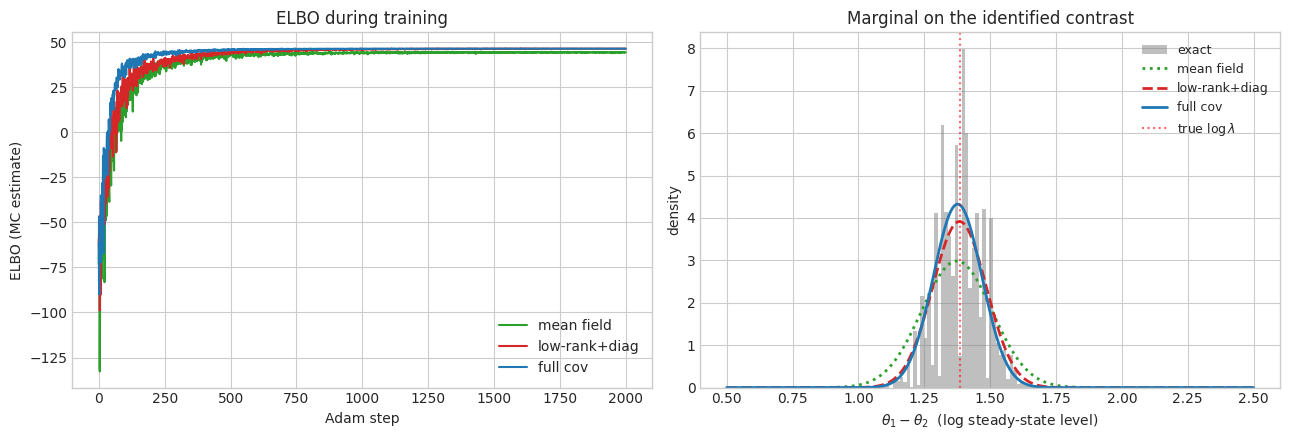

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: ELBO traces
ax = axes[0]
ax.plot(trace_diag, label='mean field', color='#2ca02c')
ax.plot(trace_lr,   label='low-rank+diag', color='#d62728')
ax.plot(trace_full, label='full cov',  color='#1f77b4')
ax.set_xlabel('Adam step')
ax.set_ylabel('ELBO (MC estimate)')
ax.set_title('ELBO during training')
ax.legend()

# Right: Marginal on theta1 - theta2 (the well-identified contrast)
ax = axes[1]
diff_grid = np.linspace(0.5, 2.5, 400)
# Exact marginal of t1 - t2 by integrating along anti-diagonal
from scipy.ndimage import map_coordinates
# Cheaper: histogram-style by sampling from the grid
samples_idx = np.random.choice(post.size, size=80000, p=(post/post.sum()).ravel())
ii, jj = np.unravel_index(samples_idx, post.shape)
diff_samples_exact = T1[ii, jj] - T2[ii, jj]
ax.hist(diff_samples_exact, bins=60, density=True, color='gray', alpha=0.5,
        label='exact')

for q_mu, q_Sigma, color, style, label in [
    (mu_diag, Sigma_diag, '#2ca02c', ':',  'mean field'),
    (mu_lr,   Sigma_lr,   '#d62728', '--', 'low-rank+diag'),
    (mu_full, Sigma_full, '#1f77b4', '-',  'full cov'),
]:
    m, s = contrast_stats(q_mu, q_Sigma)
    pdf = np.exp(-0.5 * ((diff_grid - m) / s) ** 2) / (s * np.sqrt(2*np.pi))
    ax.plot(diff_grid, pdf, color=color, linestyle=style, linewidth=2, label=label)

ax.axvline(np.log(lambda_true), color='red', linestyle=':', alpha=0.6,
           label=r'true $\log \lambda$')
ax.set_xlabel(r'$\theta_1 - \theta_2$  (log steady-state level)')
ax.set_ylabel('density')
ax.set_title('Marginal on the identified contrast')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Step 9: Why Mean-Field is Over-Confident

$D_{\mathrm{KL}}(q \| p)$ is **mode-seeking**: it penalizes putting mass where $p$ is zero, so it shrinks $q$ to fit *inside* the high-probability region of $p$. For a diagonal-Gaussian $q$ approximating a tilted posterior, the only way to fit *inside* the diagonal ridge is to **shrink to a point near its center** — losing variance in both directions.

The full-covariance and low-rank+diag families instead align their major axis with the ridge, recovering the right variance in the well-identified direction (small variance along $\theta_1 - \theta_2$) and in the unidentified direction (large variance along $\theta_1 + \theta_2$, set by the prior).

This is exactly the lesson of **Figure 10.2** in PML-2: in high-dim posteriors with structure, even cheap rank-1 corrections are worth a lot.

## Summary

### What we built
We posed a Bayesian inference problem with a structured 2D posterior — joint inference of mRNA synthesis and degradation rates from steady-state RNA-seq counts — and fit it three ways using **reparameterized variational inference**:

| Family | Parameters | Captures correlation? | Practical use |
|---|---|---|---|
| Diagonal (mean field) | $2d$ | No | Default for VAEs, fast, often over-confident |
| Full (Cholesky) | $d(d+3)/2$ | Yes | Best fit, but $O(d^2)$ scaling |
| Low-rank + diag | $3d$ (rank 1) | Yes, the dominant direction | Excellent compromise in high dim (Eq. 10.57) |

### Key takeaways from PML-2 §10.2
1. **Reparameterization** turns an expectation under $q_{\boldsymbol{\psi}}$ into one under a fixed noise distribution, letting gradients flow through samples (Eq. 10.36–10.40).
2. The **diagonal Gaussian** is the easiest reparameterization (Eq. 10.44) but cannot capture posterior correlation — a well-known mode-seeking failure of $D_{\mathrm{KL}}(q \| p)$.
3. The **full Cholesky** parameterization captures all correlations but costs $O(d^2)$ parameters and decomposition.
4. The **low-rank + diagonal** factorization (VAFC, Eq. 10.57) costs only $O(d)$ extra parameters yet recovers the dominant correlation direction — often nearly as good as full covariance.
5. Everything composes with **SVI** (minibatching, Section 10.1.4) and **amortization** (inference networks, Section 10.1.5), so the same gradient estimator scales to large datasets and neural-network posteriors.